In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
conn = duckdb.connect()


conn.execute("CREATE TABLE orders AS SELECT * FROM read_csv_auto('../data/raw/olist_orders_dataset.csv')")
conn.execute("CREATE TABLE customers AS SELECT * FROM read_csv_auto('../data/raw/olist_customers_dataset.csv')")
conn.execute("CREATE TABLE order_items AS SELECT * FROM read_csv_auto('../data/raw/olist_order_items_dataset.csv')")
conn.execute("CREATE TABLE payments AS SELECT * FROM read_csv_auto('../data/raw/olist_order_payments_dataset.csv')")
conn.execute("CREATE TABLE reviews AS SELECT * FROM read_csv_auto('../data/raw/olist_order_reviews_dataset.csv')")
conn.execute("CREATE TABLE products AS SELECT * FROM read_csv_auto('../data/raw/olist_products_dataset.csv')")
conn.execute("CREATE TABLE sellers AS SELECT * FROM read_csv_auto('../data/raw/olist_sellers_dataset.csv')")

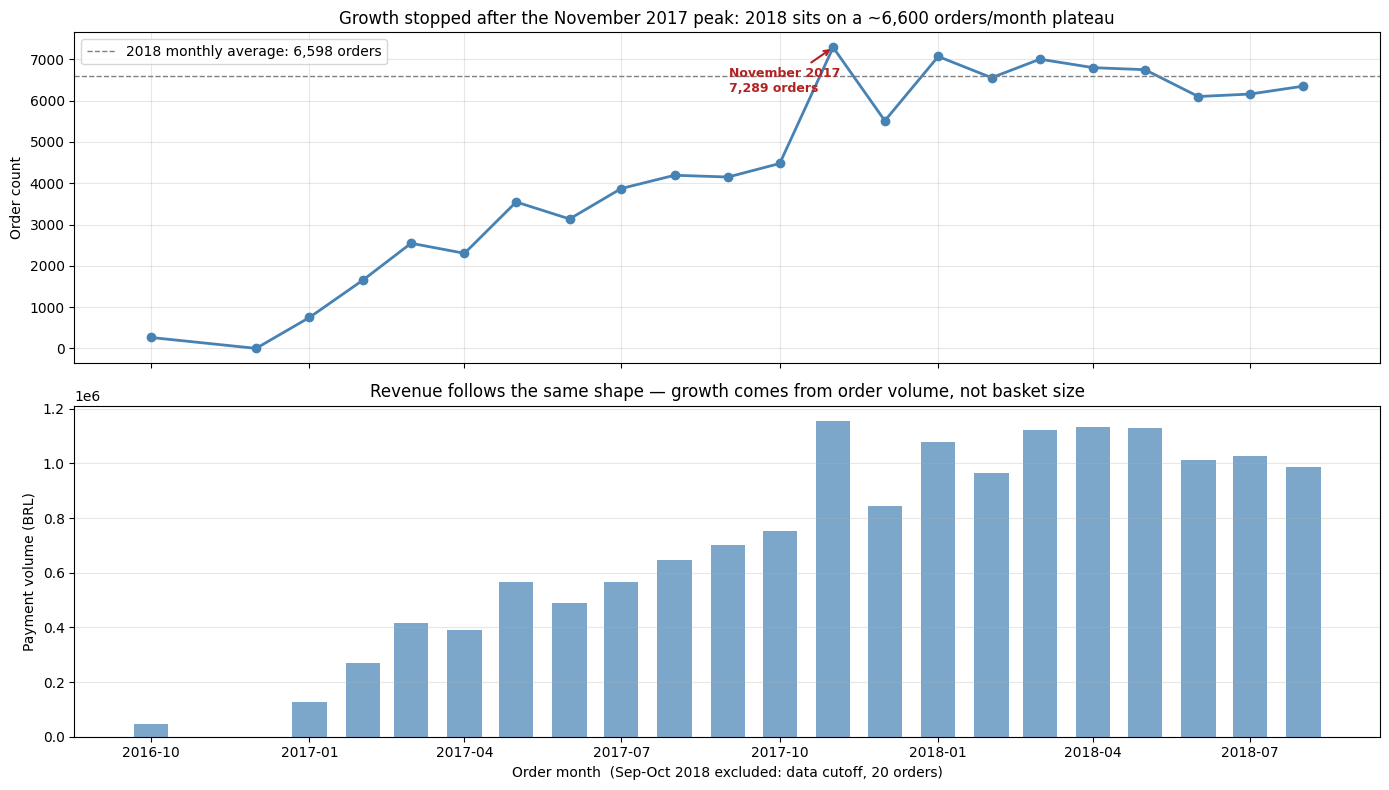


FINDING: Month over month, the series settles onto a plateau after the November 2017 peak (7,289 orders): the first 8 months of 2018 average 6,598 orders per month. Year over year, however, growth continues — it is only slowing: January 9.4x, August 1.51x (see 04_findings, Question 1).
BUSINESS READING: The 2018 plateau is not a collapse; it is the end of 2017's low base. The two readings lead to different decisions and must not be confused. Growth targets should be tracked through the YoY growth multiple rather than absolute order count.
CAVEAT: Monthly aggregation hides intra-month concentration — this peak is squeezed into a single day (see the November breakdown below).



In [2]:
monthly = conn.execute("""
    SELECT
        strftime(o.order_purchase_timestamp, '%Y-%m') AS month,
        COUNT(DISTINCT o.order_id)                    AS order_count,
        ROUND(SUM(p.payment_value), 2)                AS total_revenue
    FROM orders o
    JOIN payments p ON o.order_id = p.order_id
    WHERE o.order_status = 'delivered'
      AND o.order_purchase_timestamp < '2018-09-01'   -- Sep/Oct 2018 is a data cutoff, not a trend
    GROUP BY 1
    ORDER BY 1
""").df()


monthly['month'] = pd.to_datetime(monthly['month'], format='%Y-%m')

plateau = monthly[monthly['month'] >= '2018-01-01']['order_count'].mean()
peak = monthly.loc[monthly['order_count'].idxmax()]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(monthly['month'], monthly['order_count'], marker='o', linewidth=2, color='steelblue')
axes[0].axhline(plateau, color='gray', linestyle='--', linewidth=1,
                label=f'2018 monthly average: {plateau:,.0f} orders')
axes[0].annotate("November 2017\n{:,.0f} orders".format(peak['order_count']),
                 xy=(peak['month'], peak['order_count']),
                 xytext=(-75, -32), textcoords='offset points',
                 arrowprops=dict(arrowstyle='->', color='firebrick', linewidth=1.5),
                 fontsize=9, color='firebrick', fontweight='bold')
axes[0].set_title("Growth stopped after the November 2017 peak: 2018 sits on a ~6,600 orders/month plateau")
axes[0].set_ylabel('Order count')
axes[0].legend(loc='upper left')
axes[0].grid(alpha=0.3)

axes[1].bar(monthly['month'], monthly['total_revenue'], width=20, color='steelblue', alpha=0.7)
axes[1].set_title('Revenue follows the same shape — growth comes from order volume, not basket size')
axes[1].set_ylabel('Payment volume (BRL)')
axes[1].set_xlabel("Order month  (Sep-Oct 2018 excluded: data cutoff, 20 orders)")
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../reports/01_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()


print("""
FINDING: Month over month, the series settles onto a plateau after the November 2017 peak (7,289 orders): the first 8 months of 2018 average 6,598 orders per month. Year over year, however, growth continues — it is only slowing: January 9.4x, August 1.51x (see 04_findings, Question 1).
BUSINESS READING: The 2018 plateau is not a collapse; it is the end of 2017's low base. The two readings lead to different decisions and must not be confused. Growth targets should be tracked through the YoY growth multiple rather than absolute order count.
CAVEAT: Monthly aggregation hides intra-month concentration — this peak is squeezed into a single day (see the November breakdown below).
""")

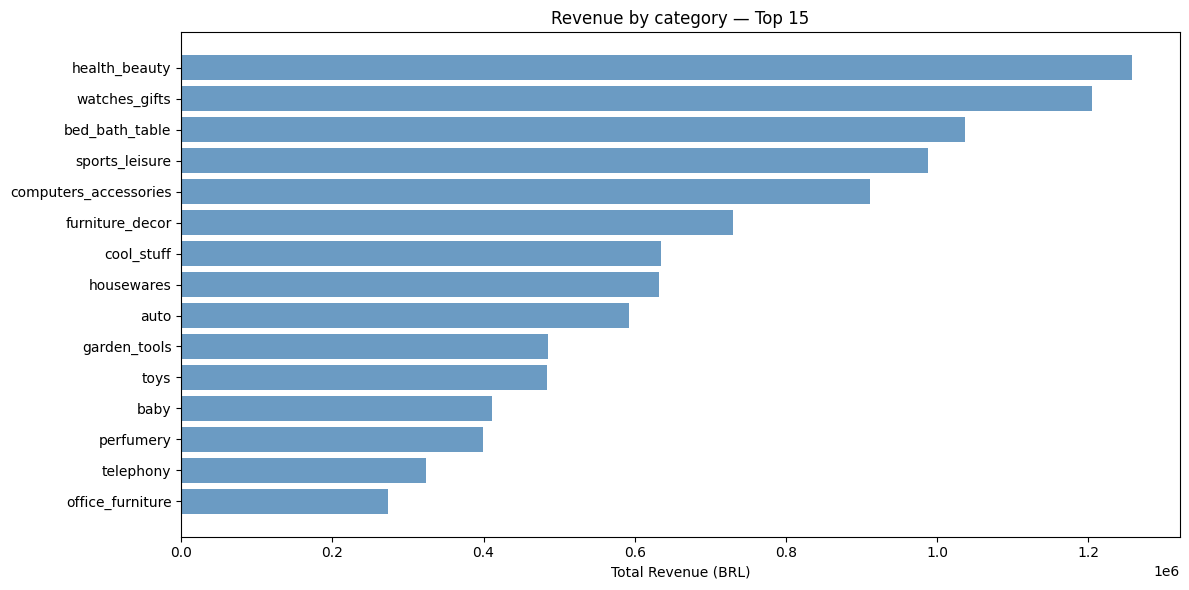

In [3]:
category = conn.execute("""
    SELECT
        COALESCE(t.product_category_name_english, p.product_category_name) AS category,
        COUNT(DISTINCT oi.order_id) AS orders,
        ROUND(SUM(oi.price), 2) AS revenue
    FROM products p
    JOIN order_items oi ON p.product_id = oi.product_id
    LEFT JOIN (
        SELECT * FROM read_csv_auto('../data/raw/product_category_name_translation.csv')
    ) t ON p.product_category_name = t.product_category_name
    GROUP BY 1
    ORDER BY revenue DESC
    LIMIT 15
""").df()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(category['category'], category['revenue'], color='steelblue', alpha=0.8)
ax.set_xlabel('Total Revenue (BRL)')
ax.set_title('Revenue by category — Top 15')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/02_category_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

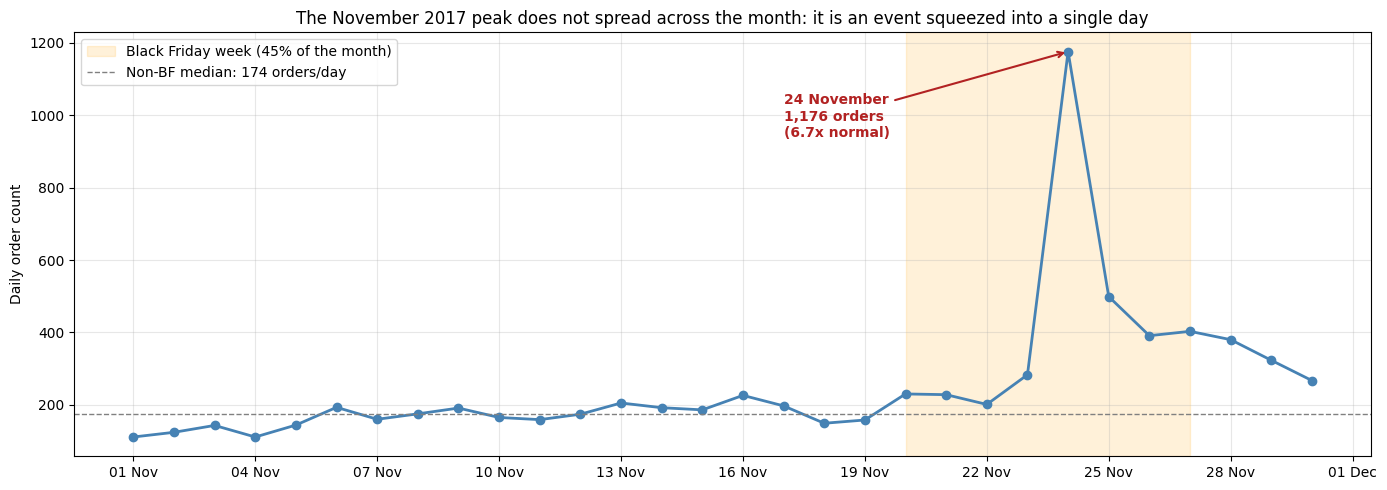


FINDING: The November 2017 peak is not month-long performance; it is an event squeezed into a single day. 24 November (Black Friday) alone produced 1,176 orders — against a median of 174 orders on the month's non-BF days, i.e. 6.7x the daily volume. The 20-27 November window accounts for 45% of the month's total orders.
BUSINESS READING: This breakdown invalidates the suggestion "let's spread the November campaign strategy across the other months of the year" — there is no monthly strategy to spread, only a one-day discount effect. The right question is: do the customers who arrive on this single day come back?



In [4]:
import matplotlib.dates as mdates


november = conn.execute("""
    SELECT
        CAST(order_purchase_timestamp AS DATE) AS day,
        COUNT(*)                               AS orders
    FROM orders
    WHERE order_purchase_timestamp >= '2017-11-01'
      AND order_purchase_timestamp <  '2017-12-01'
    GROUP BY 1
    ORDER BY 1
""").df()
november['day'] = pd.to_datetime(november['day'])

bf_start, bf_end = pd.Timestamp('2017-11-20'), pd.Timestamp('2017-11-27')
bf_mask = (november['day'] >= bf_start) & (november['day'] <= bf_end)
bf_share = 100 * november.loc[bf_mask, 'orders'].sum() / november['orders'].sum()
peak = november.loc[november['orders'].idxmax()]
normal_day = november.loc[~bf_mask, 'orders'].median()

fig, ax = plt.subplots(figsize=(14, 5))
ax.axvspan(bf_start, bf_end, color='orange', alpha=0.15,
           label=f'Black Friday week ({bf_share:.0f}% of the month)')
ax.plot(november['day'], november['orders'], marker='o', linewidth=2, color='steelblue')
ax.axhline(normal_day, color='gray', linestyle='--', linewidth=1,
           label=f'Non-BF median: {normal_day:.0f} orders/day')
ax.annotate(f"{peak['day']:%d November}\n{peak['orders']:,.0f} orders\n({peak['orders']/normal_day:.1f}x normal)",
            xy=(peak['day'], peak['orders']),
            xytext=(peak['day'] - pd.Timedelta(days=7), peak['orders'] * 0.80),
            arrowprops=dict(arrowstyle='->', color='firebrick', linewidth=1.5),
            fontsize=10, color='firebrick', fontweight='bold')
ax.set_title('The November 2017 peak does not spread across the month: it is an event squeezed into a single day')
ax.set_ylabel('Daily order count')
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/04_nov2017_daily.png', dpi=150, bbox_inches='tight')
plt.show()


print("""
FINDING: The November 2017 peak is not month-long performance; it is an event squeezed into a single day. 24 November (Black Friday) alone produced 1,176 orders — against a median of 174 orders on the month's non-BF days, i.e. 6.7x the daily volume. The 20-27 November window accounts for 45% of the month's total orders.
BUSINESS READING: This breakdown invalidates the suggestion "let's spread the November campaign strategy across the other months of the year" — there is no monthly strategy to spread, only a one-day discount effect. The right question is: do the customers who arrive on this single day come back?
""")

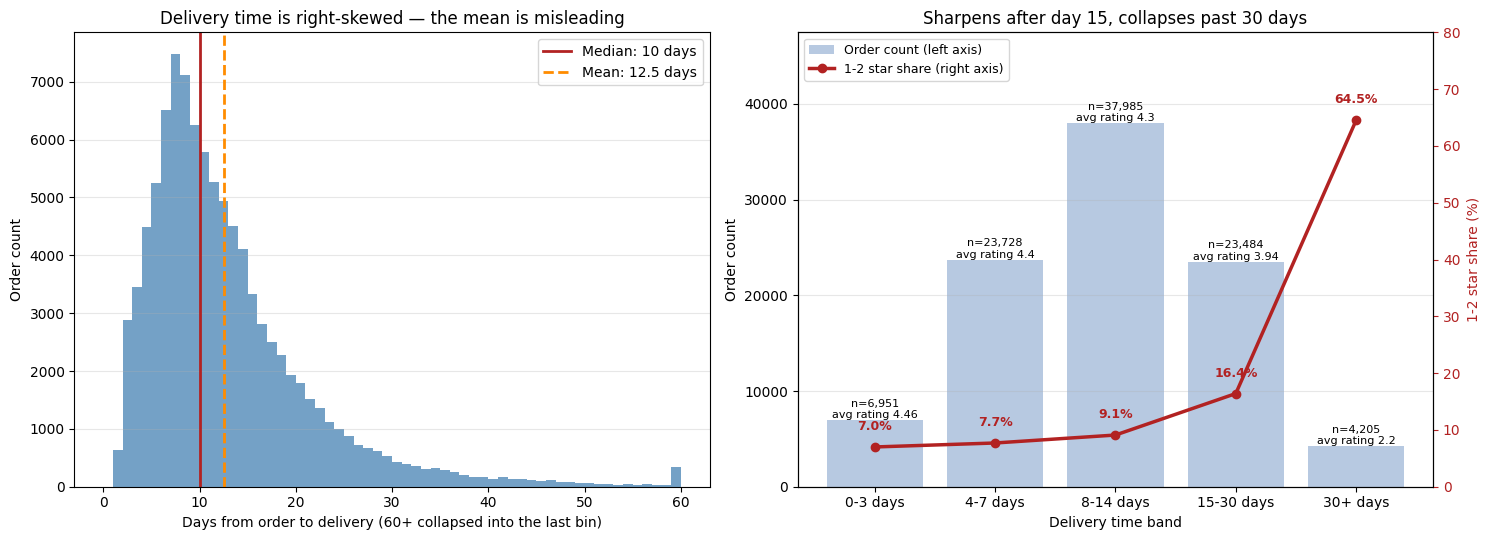


FINDING: There is a strong, one-directional relationship between delivery time and satisfaction. The distribution is right-skewed: median 10 days, mean 12.5 days — which is why an "average delivery time" metric hides the tail. The effect sharpens after day 15: the 1-2 star share rises from 9.1% to 16.4%, and jumps to 64.5% past 30 days.
BUSINESS READING: The 4,205 orders that waited 30+ days are only 4.4% of total volume but produce a very large share of the bad ratings. The cheapest way to raise satisfaction is not to improve the average but to cut this tail. Caveat: this is an observational correlation — the link between late delivery and low ratings may also be driven by common causes (remote region, problematic seller).



In [5]:
delivery = conn.execute("""
    SELECT DATE_DIFF('day', o.order_purchase_timestamp, o.order_delivered_customer_date) AS days
    FROM orders o
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
""").df()

bands = conn.execute("""
    SELECT
        CASE WHEN days <=  3 THEN '0-3 days'
             WHEN days <=  7 THEN '4-7 days'
             WHEN days <= 14 THEN '8-14 days'
             WHEN days <= 30 THEN '15-30 days'
             ELSE '30+ days' END                                                AS delivery_band,
        COUNT(*)                                                                AS orders,
        ROUND(AVG(rating), 2)                                                   AS avg_rating,
        ROUND(100.0 * SUM(CASE WHEN rating <= 2 THEN 1 ELSE 0 END) / COUNT(*), 1) AS low_rating_pct
    FROM (
        SELECT DATE_DIFF('day', o.order_purchase_timestamp, o.order_delivered_customer_date) AS days,
               r.review_score AS rating
        FROM orders o
        JOIN reviews r ON o.order_id = r.order_id
        WHERE o.order_status = 'delivered'
          AND o.order_delivered_customer_date IS NOT NULL
    )
    GROUP BY 1
    ORDER BY MIN(days)
""").df()

median, mean = delivery['days'].median(), delivery['days'].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))


ax1.hist(delivery['days'].clip(upper=60), bins=60, color='steelblue', alpha=0.75)
ax1.axvline(median, color='firebrick',  linestyle='-',  linewidth=2, label=f'Median: {median:.0f} days')
ax1.axvline(mean,   color='darkorange', linestyle='--', linewidth=2, label=f'Mean: {mean:.1f} days')
ax1.set_title('Delivery time is right-skewed — the mean is misleading')
ax1.set_xlabel("Days from order to delivery (60+ collapsed into the last bin)")
ax1.set_ylabel('Order count')
ax1.legend()
ax1.grid(alpha=0.3, axis='y')


x = range(len(bands))
ax2.bar(x, bands['orders'], color='lightsteelblue', alpha=0.9, label='Order count (left axis)')
ax2.set_xticks(list(x))
ax2.set_xticklabels(bands['delivery_band'])
ax2.set_xlabel('Delivery time band')
ax2.set_ylabel('Order count')
ax2.set_ylim(0, bands['orders'].max() * 1.25)
for xi, (n, rating) in enumerate(zip(bands['orders'], bands['avg_rating'])):
    ax2.text(xi, n, f'n={n:,.0f}\navg rating {rating}', ha='center', va='bottom', fontsize=8)

ax2b = ax2.twinx()
ax2b.plot(x, bands['low_rating_pct'], marker='o', color='firebrick', linewidth=2.5,
          label='1-2 star share (right axis)')
for xi, pct in zip(x, bands['low_rating_pct']):
    ax2b.text(xi, pct + 3, f'{pct}%', ha='center', color='firebrick', fontsize=9, fontweight='bold')
ax2b.set_ylabel('1-2 star share (%)', color='firebrick')
ax2b.tick_params(axis='y', colors='firebrick')
ax2b.set_ylim(0, 80)

ax2.set_title('Sharpens after day 15, collapses past 30 days')
h1, l1 = ax2.get_legend_handles_labels()
h2, l2 = ax2b.get_legend_handles_labels()
ax2.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=9)
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../reports/05_delivery_satisfaction.png', dpi=150, bbox_inches='tight')
plt.show()


print("""
FINDING: There is a strong, one-directional relationship between delivery time and satisfaction. The distribution is right-skewed: median 10 days, mean 12.5 days — which is why an "average delivery time" metric hides the tail. The effect sharpens after day 15: the 1-2 star share rises from 9.1% to 16.4%, and jumps to 64.5% past 30 days.
BUSINESS READING: The 4,205 orders that waited 30+ days are only 4.4% of total volume but produce a very large share of the bad ratings. The cheapest way to raise satisfaction is not to improve the average but to cut this tail. Caveat: this is an observational correlation — the link between late delivery and low ratings may also be driven by common causes (remote region, problematic seller).
""")

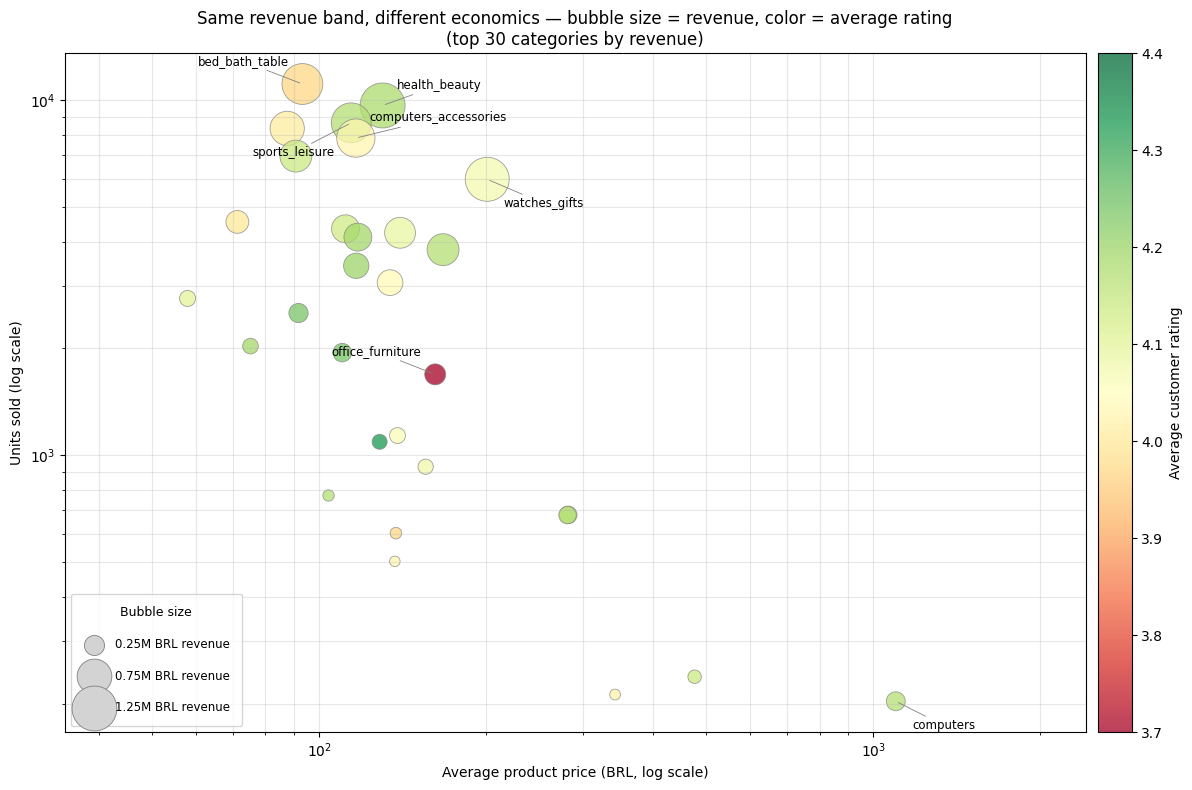

             category  units_sold   revenue  avg_price  freight_load_pct  avg_rating
        health_beauty        9670 1258681.0      130.2              14.5        4.18
        watches_gifts        5991 1205006.0      201.1               8.3        4.07
       bed_bath_table       11115 1036989.0       93.3              19.7        3.97
       sports_leisure        8641  988049.0      114.3              17.1        4.17
computers_accessories        7827  911954.0      116.5              16.2        4.03
      furniture_decor        8334  729762.0       87.6              23.7        4.01
           cool_stuff        3796  635291.0      167.4              13.2        4.17
           housewares        6964  632249.0       90.8              23.1        4.14
                 auto        4235  592720.0      140.0              15.6        4.09
         garden_tools        4347  485256.0      111.6              20.4        4.13

FINDING: Revenue rank alone is misleading — categories in the sa

In [6]:
cat = conn.execute("""
    WITH item AS (
        SELECT COALESCE(t.product_category_name_english, p.product_category_name) AS category,
               oi.order_id, oi.price, oi.freight_value
        FROM order_items oi
        JOIN products p ON oi.product_id = p.product_id
        LEFT JOIN read_csv_auto('../data/raw/product_category_name_translation.csv') t
               ON p.product_category_name = t.product_category_name
        WHERE p.product_category_name IS NOT NULL
    ),
    metrics AS (
        SELECT category,
               COUNT(*)                                       AS units_sold,
               ROUND(SUM(price))                              AS revenue,
               ROUND(AVG(price), 1)                           AS avg_price,
               ROUND(100.0*SUM(freight_value)/SUM(price), 1)  AS freight_load_pct
        FROM item GROUP BY 1
    ),
    -- Ratings are averaged at order level: an item-level JOIN would repeat the same
    -- review for multi-item orders and distort its weight.
    rating AS (
        SELECT u.category, ROUND(AVG(r.review_score), 2) AS avg_rating
        FROM (SELECT DISTINCT category, order_id FROM item) u
        JOIN reviews r ON u.order_id = r.order_id
        GROUP BY 1
    )
    SELECT m.*, r.avg_rating
    FROM metrics m LEFT JOIN rating r ON m.category = r.category
    ORDER BY m.revenue DESC
    LIMIT 30
""").df()

fig, ax = plt.subplots(figsize=(13, 8))
sc = ax.scatter(cat['avg_price'], cat['units_sold'],
                s=cat['revenue'] / 1200, c=cat['avg_rating'],
                cmap='RdYlGn', vmin=3.7, vmax=4.4,
                alpha=0.75, edgecolors='gray', linewidths=0.6)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Average product price (BRL, log scale)')
ax.set_ylabel('Units sold (log scale)')
ax.set_title('Same revenue band, different economics — bubble size = revenue, color = average rating\n(top 30 categories by revenue)')
ax.grid(alpha=0.3, which='both')

cb = plt.colorbar(sc, ax=ax, pad=0.01)
cb.set_label('Average customer rating')

# Leave room on the x axis so labels don't overflow on the right
ax.set_xlim(cat['avg_price'].min() * 0.6, cat['avg_price'].max() * 2.2)

# Label the top 5 by revenue + the extremes, so the chart stays readable.
# Points overlap in the upper cluster; label offsets alternate by rank.
labels = list(dict.fromkeys(
    list(cat.nlargest(5, 'revenue')['category'])
    + list(cat.nlargest(1, 'avg_price')['category'])
    + list(cat.nlargest(1, 'units_sold')['category'])
    + list(cat.nsmallest(2, 'avg_rating')['category'])
))
offsets = [(10, 12), (12, -20), (-10, 14), (-12, -24)]
for rank, name in enumerate(labels):
    r = cat[cat['category'] == name].iloc[0]
    dx, dy = offsets[rank % len(offsets)]
    ax.annotate(name, xy=(r['avg_price'], r['units_sold']),
                xytext=(dx, dy), textcoords='offset points', fontsize=8.5,
                ha='left' if dx > 0 else 'right',
                arrowprops=dict(arrowstyle='-', color='gray', linewidth=0.6, shrinkA=0, shrinkB=2))

# Scale reference for bubble size
for ref in [250_000, 750_000, 1_250_000]:
    ax.scatter([], [], s=ref / 1200, c='lightgray', edgecolors='gray', linewidths=0.6,
               label=f'{ref/1e6:.2f}M BRL revenue')
ax.legend(loc='lower left', labelspacing=1.6, borderpad=1.0,
          frameon=True, fontsize=8.5, title='Bubble size', title_fontsize=9)

plt.tight_layout()
plt.savefig('../reports/06_category_economics.png', dpi=150, bbox_inches='tight')
plt.show()

print(cat.head(10).to_string(index=False))
print("""
FINDING: Revenue rank alone is misleading — categories in the same revenue band have completely different economics. health_beauty produces 1.26M BRL from 9,670 units x 130 BRL, while watches_gifts reaches almost the same revenue (1.21M) from 5,991 units x 201 BRL: one is a volume business, the other a price business. bed_bath_table is the best-selling category (11,115 units) but, with a 93 BRL average price, 19.7% freight load and a 3.97 rating, it has one of the weakest economics on the list.
BUSINESS READING: Category investment cannot be based on revenue rank. In volume categories (bed_bath_table, furniture_decor) the lever is freight cost; in price categories (watches_gifts) the lever is conversion rate. office_furniture has the lowest satisfaction on the list at 3.7 — despite its revenue contribution, its operational problem should be investigated first.
CAVEAT: With no margin data, this chart shows revenue, not profitability; the ranking could differ on a margin basis.
""")